In [4]:
import pandas as pd
import pyodbc
import numpy as np
from sqlalchemy import create_engine
import urllib
import matplotlib.pyplot as plt 
import seaborn as sns
from warnings import filterwarnings

In [5]:
conn = pyodbc.connect('DRIVER={SQL Server};SERVER=LAPTOP-JF5CSB68\SQLEXPRESS;DATABASE=My_Project;Trusted_Connection=yes;')
if conn:
    print("Connection successful!")

Connection successful!


<>:1: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:1: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
C:\Users\SAHIL\AppData\Local\Temp\ipykernel_9432\1838932837.py:1: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  conn = pyodbc.connect('DRIVER={SQL Server};SERVER=LAPTOP-JF5CSB68\SQLEXPRESS;DATABASE=My_Project;Trusted_Connection=yes;')


In [6]:

# 1. Setup the connection parameters
params = urllib.parse.quote_plus(
    r'DRIVER={ODBC Driver 17 for SQL Server};'
    r'SERVER=LAPTOP-JF5CSB68\SQLEXPRESS;' # Use your server name
    r'DATABASE=My_Project;'
    r'Trusted_Connection=yes;'
)

# 2. Create the engine (The "Connectable" Pandas is asking for)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

# 3. Read the data using the engine
df = pd.read_sql_query("SELECT * FROM Final_Summary_Table", con=engine)

In [7]:
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,SalestoPurchaseRatio,StockTurnover
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.270000,36.990002,1750.0,145080,3.811252e+06,142049.0,5101919.51,672819.31,260999.20,68601.680141,1.290668e+06,25.297693,1.338647,0.979108
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.190001,28.990000,1750.0,164038,3.804041e+06,160247.0,4819073.49,561512.37,294438.66,144929.240166,1.015032e+06,21.062809,1.266830,0.976890
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.240000,24.990000,1750.0,187407,3.418304e+06,187140.0,4538120.60,461140.15,343854.07,123780.220203,1.119817e+06,24.675786,1.327594,0.998575
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.170000,22.990000,1750.0,201682,3.261198e+06,200412.0,4475972.88,420050.01,368242.80,257032.069523,1.214775e+06,27.139908,1.372493,0.993703
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.889999,29.990000,1750.0,138109,3.023206e+06,135838.0,4223107.62,545778.28,249587.83,257032.069523,1.199902e+06,28.412765,1.396897,0.983556


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,10650.649458,18753.519148,2.000000,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,18039.228769,12662.187074,58.000000,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,24.385303,109.269376,0.360000,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,35.643671,148.246018,0.490000,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,847.330153,664.344268,0.000000,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3140.886831,11095.086769,1.000000,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,30106.693354,123067.799573,0.710000,453.457510,3655.464971,20738.244730,3.811252e+06
TotalSalesQuantity,10692.0,3077.482136,10952.851391,0.000000,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,42239.074419,167655.265984,0.000000,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,18793.783627,44952.773386,0.000000,289.710000,2857.800000,16059.562500,6.728193e+05


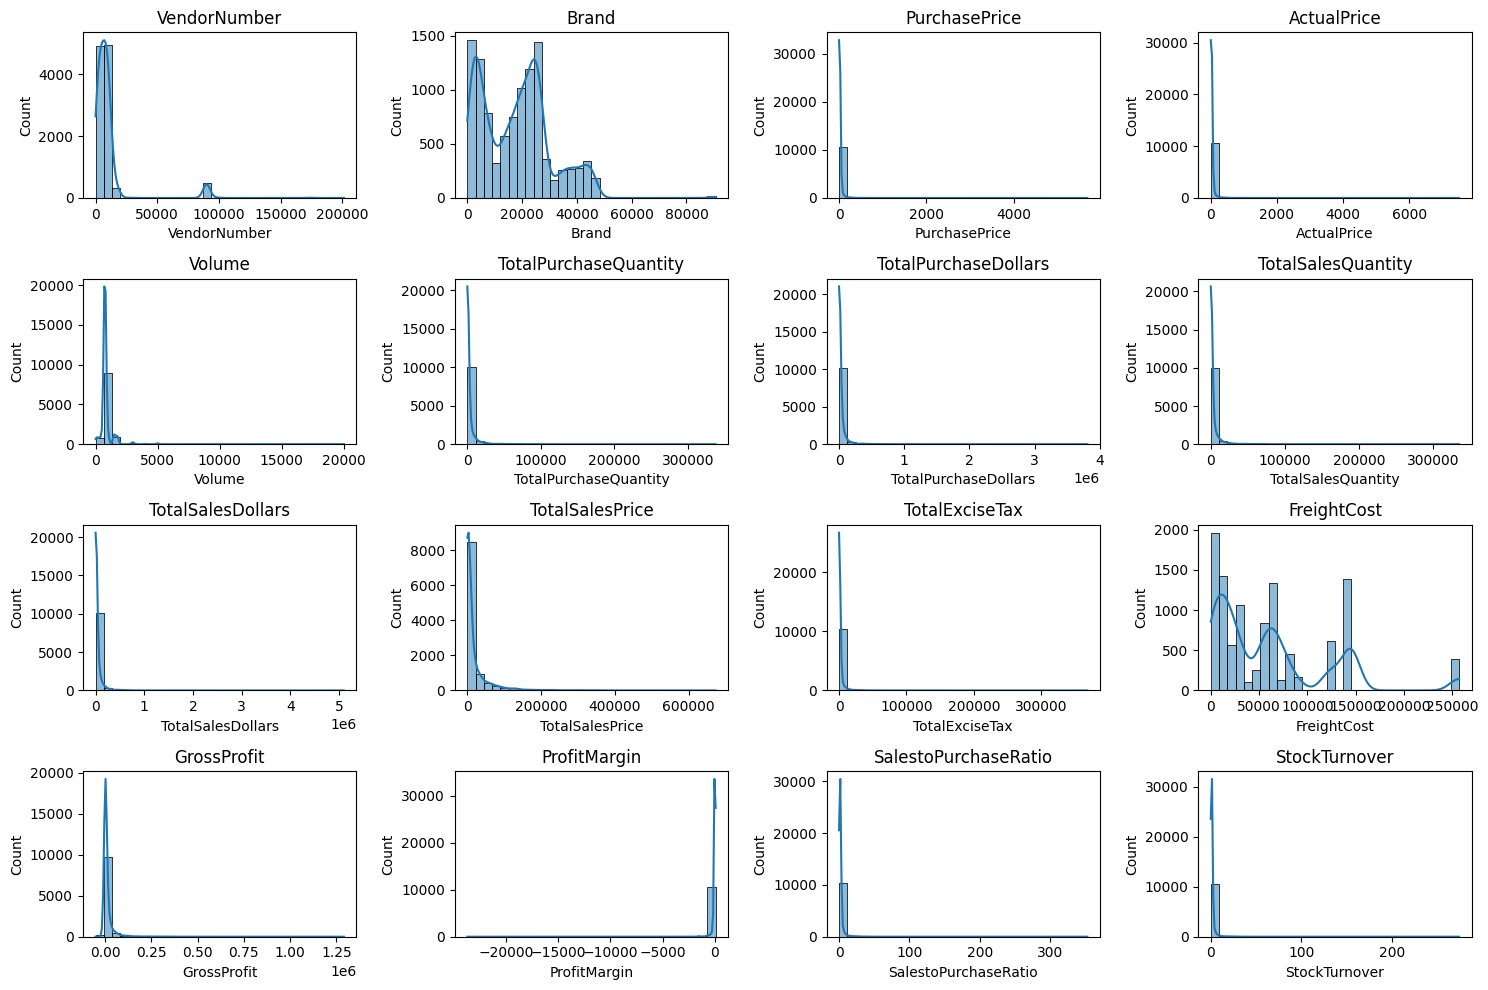

In [9]:
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

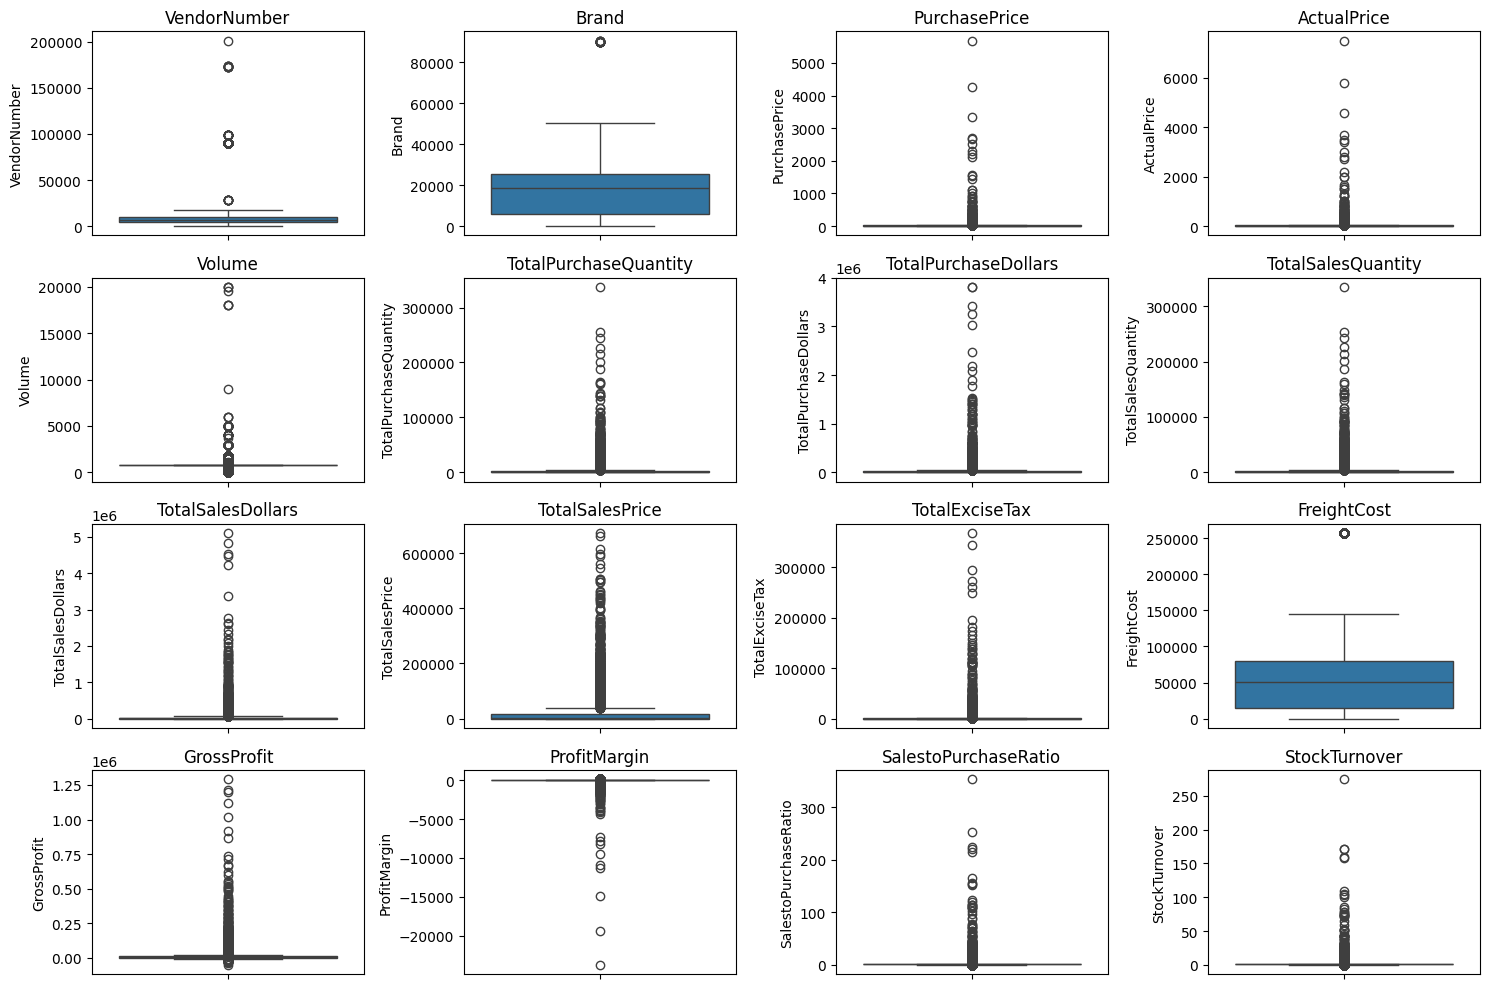

In [10]:
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [11]:
df = pd.read_sql_query("""
    select * from Final_Summary_Table     
    where GrossProfit > 0
    And ProfitMargin > 0
    And TotalSalesQuantity > 0                  
""", con=engine)
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,SalestoPurchaseRatio,StockTurnover
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.270000,36.990002,1750.0,145080,3.811252e+06,142049.0,5101919.51,672819.31,260999.20,68601.680141,1.290668e+06,25.297693,1.338647,0.979108
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.190001,28.990000,1750.0,164038,3.804041e+06,160247.0,4819073.49,561512.37,294438.66,144929.240166,1.015032e+06,21.062809,1.266830,0.976890
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.240000,24.990000,1750.0,187407,3.418304e+06,187140.0,4538120.60,461140.15,343854.07,123780.220203,1.119817e+06,24.675786,1.327594,0.998575
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.170000,22.990000,1750.0,201682,3.261198e+06,200412.0,4475972.88,420050.01,368242.80,257032.069523,1.214775e+06,27.139908,1.372493,0.993703
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.889999,29.990000,1750.0,138109,3.023206e+06,135838.0,4223107.62,545778.28,249587.83,257032.069523,1.199902e+06,28.412765,1.396897,0.983556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8560,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.320000,4.990000,750.0,2,2.640000e+00,5.0,15.95,10.96,0.55,27100.410036,1.331000e+01,83.448275,6.041666,2.500000
8561,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.390000,0.490000,50.0,6,2.340000e+00,134.0,65.66,1.47,7.04,50293.619843,6.332000e+01,96.436187,28.059830,22.333333
8562,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.740000,0.990000,50.0,2,1.480000e+00,2.0,1.98,0.99,0.10,14069.870026,5.000000e-01,25.252524,1.337838,1.000000
8563,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.470000,1.990000,200.0,1,1.470000e+00,72.0,143.28,77.61,15.12,257032.069523,1.418100e+02,98.974037,97.469386,72.000000


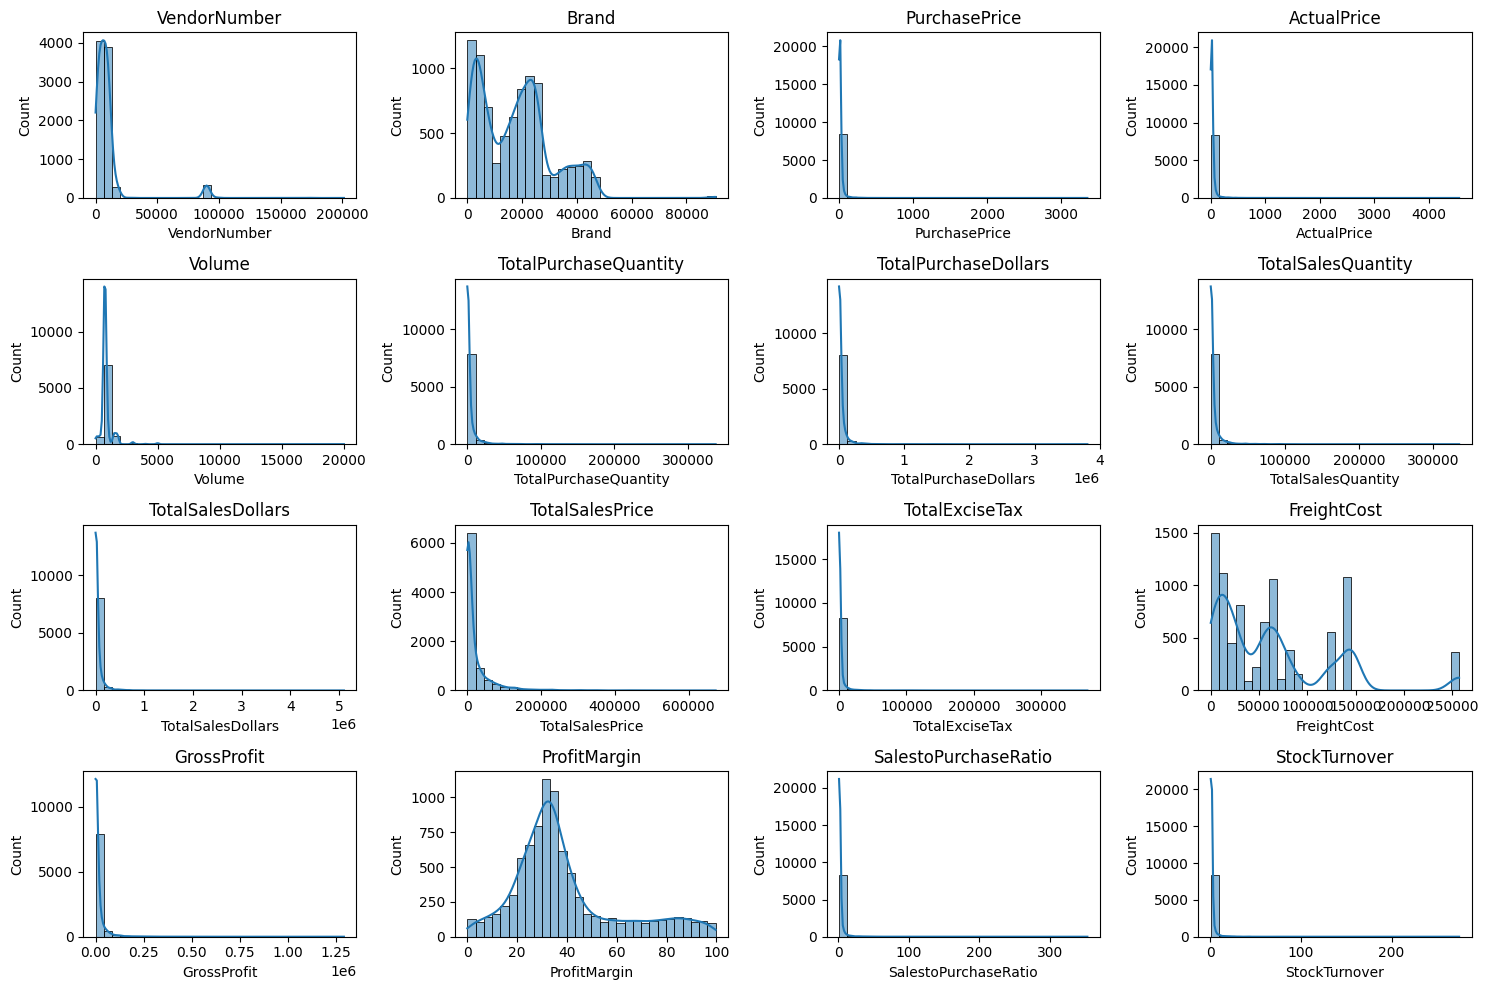

In [12]:
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

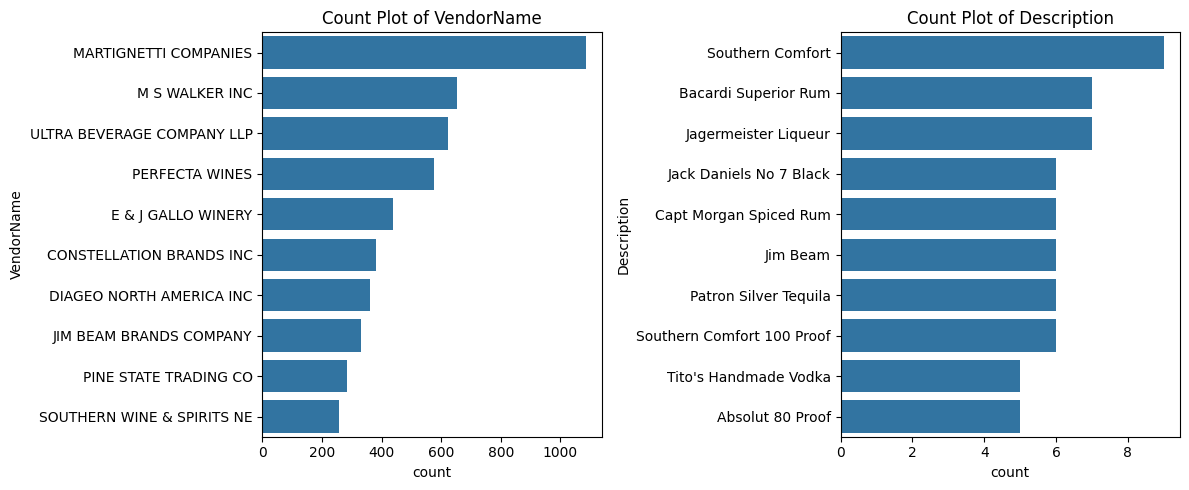

In [13]:
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12,5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1,2,i+1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10])
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

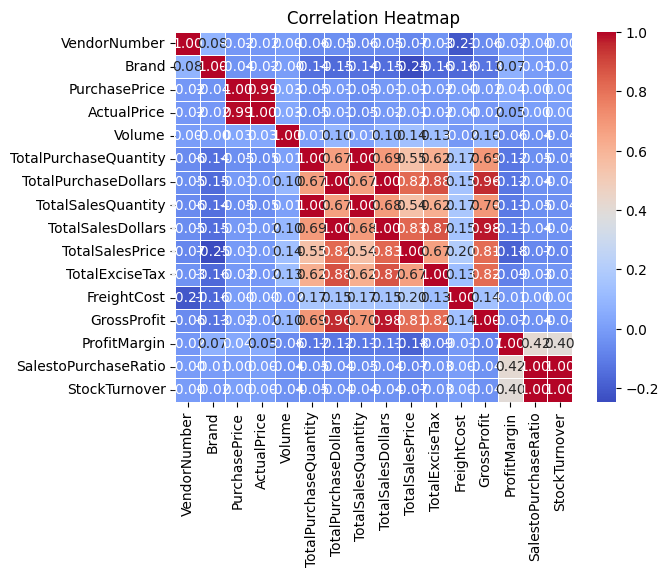

In [14]:
# correlation  heatmap
# plt.Figure(figsize=(12,24))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.Figure(figsize=(12,12))
plt.show() 

# Data Analysis

### Identify Brands that needs Promotional or Pricing Adjustment which exhibit lower sales performance but higher profit margins

In [15]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars' : 'sum',
    'ProfitMargin' : 'mean'
}).reset_index()

In [16]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [17]:
low_sales_threshold

np.float64(560.299)

In [18]:
high_margin_threshold

np.float64(64.97017464572727)

In [19]:
# Filter brands with low sales but high profit margin
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]
print("Brands with low sales but high profit margins:")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with low sales but high profit margins:


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466467
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448275
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153077
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851583
57,A Bichot Clos Marechaudes,539.94,67.740861
6245,Sbragia Home Ranch Merlot,549.75,66.444748


In [20]:
brand_performance = brand_performance[brand_performance['TotalSalesDollars']< 10000] # for better visualization

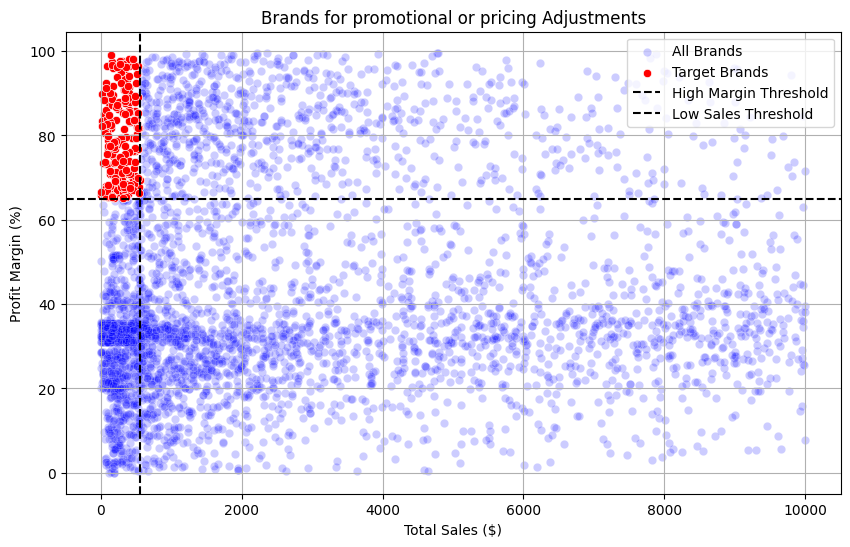

In [21]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin', color="blue", label="All Brands", alpha=0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color="red", label="Target Brands")

plt.axhline(high_margin_threshold, linestyle='--' , color='black', label="High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle='--' , color='black', label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for promotional or pricing Adjustments")
plt.legend() 
plt.grid(True)
plt.show()

## which vendors and brands demonstrate the highest sales performance?

In [22]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return str(value)

In [23]:
# Top vendors and brands by sales performance 
top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)

In [24]:
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      67990099.42
MARTIGNETTI COMPANIES         39330359.36
PERNOD RICARD USA             32063196.19
JIM BEAM BRANDS COMPANY       31423020.46
BACARDI USA INC               24854817.14
CONSTELLATION BRANDS INC      24218745.65
E & J GALLO WINERY            18399899.46
BROWN-FORMAN CORP             18247230.65
ULTRA BEVERAGE COMPANY LLP    16502544.31
M S WALKER INC                14706458.51
Name: TotalSalesDollars, dtype: float64

In [25]:
top_brands.apply(lambda x: format_dollars(x))

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: str

C:\Users\SAHIL\AppData\Local\Temp\ipykernel_9432\592416868.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values,palette="Blues_r")
C:\Users\SAHIL\AppData\Local\Temp\ipykernel_9432\592416868.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values,palette="Reds_r")


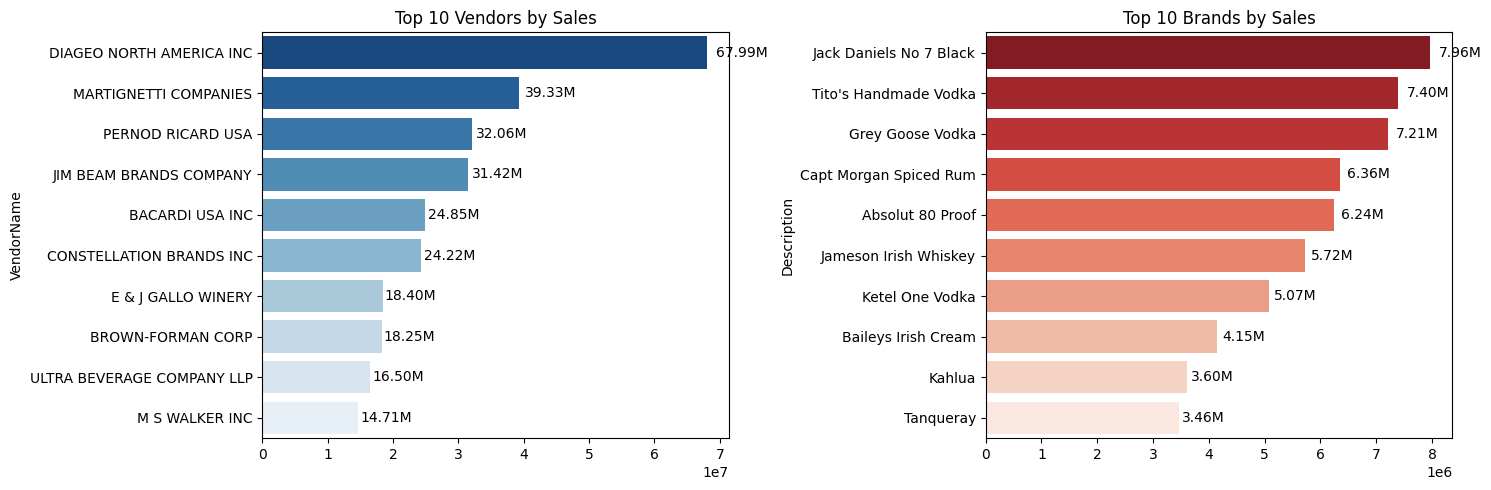

In [26]:
plt.figure(figsize=(15,5))

#Plot for Top vendors
plt.subplot(1,2,1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values,palette="Blues_r")
plt. title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
            bar.get_y() + bar.get_height() /2,
            format_dollars(bar.get_width()),
            ha='left', va='center', fontsize=10, color='black'
            )
#Plot for Top Brands
plt.subplot(1,2,2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values,palette="Reds_r")
plt. title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02),
            bar.get_y() + bar.get_height() /2,
            format_dollars(bar.get_width()),
            ha='left', va='center', fontsize=10, color='black'
            )
plt.tight_layout()
plt.show()

## Which vendors Contribute the most to total purchases dollars??

In [27]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars': 'sum',
    'GrossProfit': 'sum',
    'TotalSalesDollars' : 'sum'
}).reset_index()

In [37]:
vendor_performance['PurchaseContribution%'] = vendor_performance['TotalPurchaseDollars'] / vendor_performance['TotalPurchaseDollars'].sum() * 100

In [38]:
vendor_performance = round(vendor_performance.sort_values('PurchaseContribution%', ascending=False),2)

In [39]:
#Display Top 10 Vendors
top_vendors = vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18


In [36]:
top_vendors["Cumulative_Contribution%"] = top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_Contribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,0.16,0.16
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,0.08,0.24
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,0.08,0.32
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,0.08,0.40
6,BACARDI USA INC,17.43M,7.42M,24.85M,0.06,0.46
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,0.05,0.51
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,0.04,0.55
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,0.04,0.59
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,0.04,0.63
53,M S WALKER INC,9.76M,4.94M,14.71M,0.03,0.66


In [ ]:
fig, ax1 =  plt.subplots(figsize = (10,6))

#Bar Plot for Purchases Contribution%
sns.barplot(x=top_vendors['VendorName'], y=top_vendors['PurchaseContribution%'], palette='mako', ax= ax1)
for i,value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i, value - 1, str(value)+'%', ha="center", fontsize = 10, color='white')
    
#Line Plot for Cumulative Contribution%
ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'], top_vendors['Cumulative_Contribution%'], color='red', marker='o', linestyle='dashed', label='Cumulative %')
    

SyntaxError: expected ':' (359269564.py, line 5)